# Data Exploration notebook

**Database source:** https://archive.ics.uci.edu/dataset/320/student+performance

**Short description:**
This data approach student achievement in secondary education of two Portuguese schools. The data attributes include student grades, demographic, social and school related features and it was collected by using school reports and questionnaires.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
csvfile = pd.read_csv('student-por.csv')
df = pd.DataFrame(csvfile)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [10]:
numerical_df = df[['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']]


In [11]:
numerical_df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


## Overview

This dataset contains data about **649 Portuguese students**.  
From it, we can deduce the **average values** and **variability** of various demographic, behavioral, and academic factors.

---

## Demographics

### Age
Most of the students are around **17 years old**, which is typical for high school.  
A few are older (up to **22**), likely due to grade repetition, since Portuguese students usually graduate around the age of **18**.

### Parents’ Education
Mothers are slightly more educated than fathers, but the standard deviation shows greater variability in mothers’ education levels.  
The mean values for both parents are between **2 and 3**, corresponding to education between **5th–9th grade and secondary education**.  
This suggests that a lot of parents did not achieve the same education level their children are currently pursuing.

---

## Studying
Students usually spend **2 to 5 hours per week studying**.
Failing a class is uncommon (**mean = 0.22**), but it does occur — with the maximum recorded number of failures being **3**.

---

## Grades
Across all three grading periods (**G1**, **G2**, **G3**), the average grade is around **11–12** (out of 20).  
According to the Portuguese grading scale, this corresponds to **“Sufficient”**, indicating average overall performance.  
The steady increase from G1 to G3 suggests that **students tend to slightly improve their grades** over time.


# Correlation Heatmap of Numeric Variables

Text(0.5, 1.0, 'Correlation Heatmap of Numeric Variables')

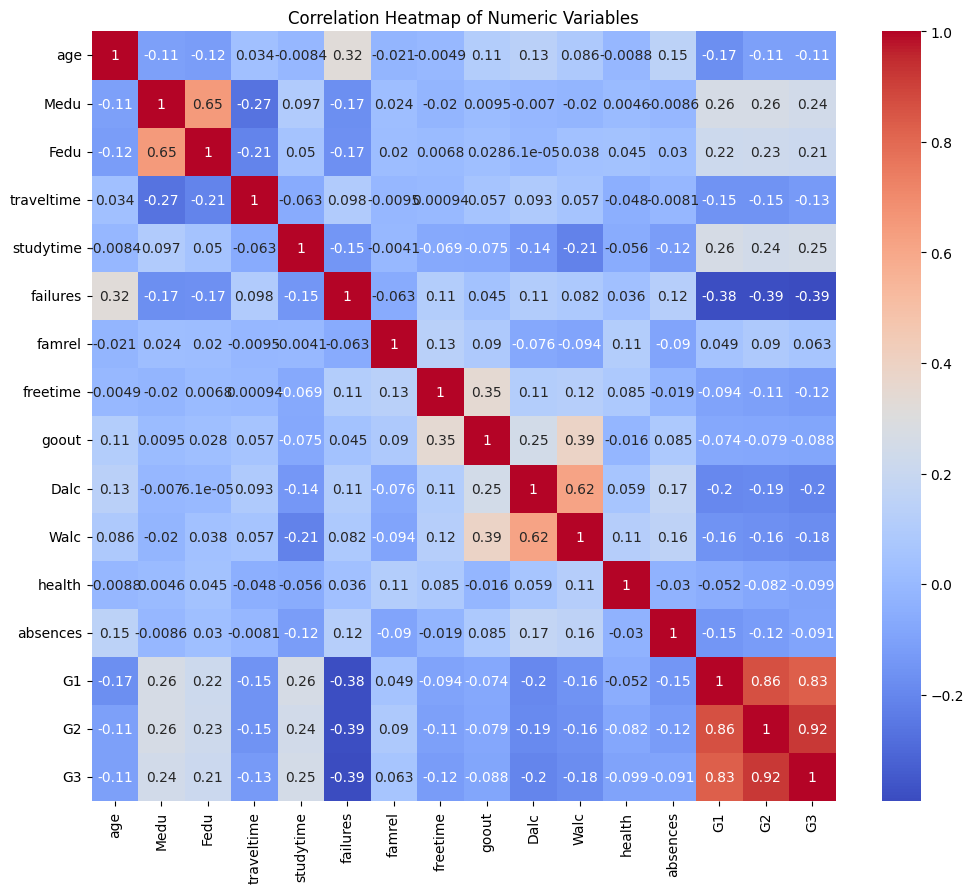

In [19]:
plt.figure(figsize=(12, 10))
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Variables")

## Correlation Insights

On the heatmap, we can see that the grades (G1, G2, G3) are strongly positively correlated.  
Students who perform well in the first period (G1) tend to perform well in the second (G2) and final period (G3).  
This indicates that academic performance is consistent over time.

Failures are negatively correlated with grades, meaning that students with lower grades are more likely to have repeated a year or failed a subject.

We can also notice a positive correlation between parents’ education levels (`Medu` and `Fedu`).  
This suggests that more educated individuals tend to form families with similarly educated partners.

There is a slight positive correlation between parental education and student grades, indicating that students with more educated parents may receive more academic support.  
However, the relationship is weak, which shows that students without highly educated parents can also achieve strong results.


# Comparison of Final Grades (G3) by Sex

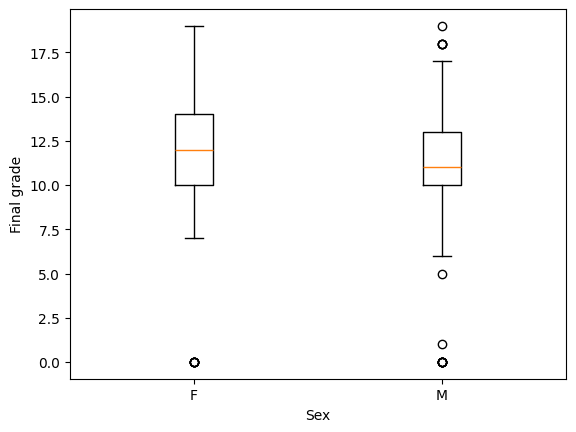

In [25]:
sexes = df['sex'].unique()

data = []
for s in sexes:
  grades = df[df['sex']==s]['G3']
  data.append(grades)

plt.boxplot(data)
plt.xlabel("Sex")
plt.ylabel("Final grade")
plt.xticks(range(1, len(sexes) + 1), sexes)
plt.show()

The boxplot shows that female students generally achieve slightly better final grades (G3) than male students.  
The median grade for girls is higher, and both the minimum and maximum values are also slightly above those of boys.  

# Comparison of Final Grades (G3) by school

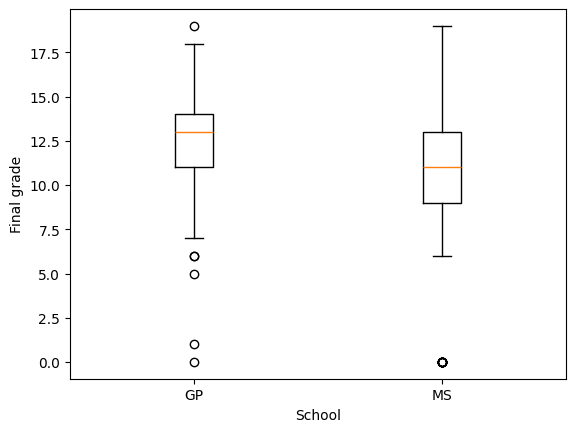

In [26]:
schools = df['school'].unique()

data = []
for s in schools:
  grades = df[df['school']==s]['G3']
  data.append(grades)

plt.boxplot(data)
plt.xlabel("School")
plt.ylabel("Final grade")
plt.xticks(range(1, len(schools) + 1), schools)
plt.show()

This plot shows that the average student performance is higher in Gabriel Pereira school (GP) than in Mousinho da Silveira (MS) school. However, the highest individual grades are achieved in MS, suggesting that while GP students perform more consistently, some MS students reach exceptional results.

# Impact of an living environment on final grades (G3)

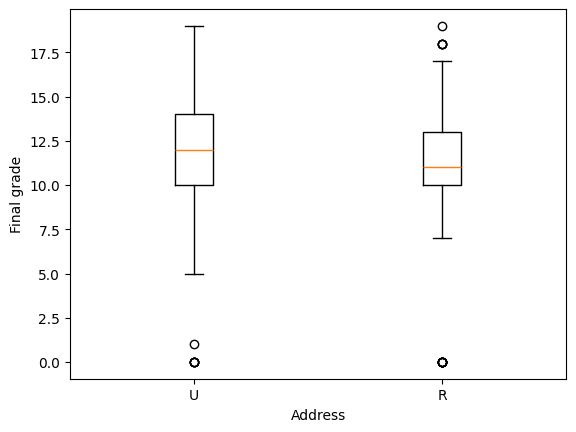

In [28]:
addresses = df['address'].unique()

data = []
for a in addresses:
  grades = df[df['address']==a]['G3']
  data.append(grades)

plt.boxplot(data)
plt.xlabel("Address")
plt.ylabel("Final grade")
plt.xticks(range(1, len(addresses) + 1), addresses)
plt.show()

This boxplot shows that students from urban areas (U) generally achieve slightly higher grades than those from rural areas (R).  
Achieving the highest scores is more common among urban students, while in rural areas, grades above 17 are treated as outliers, representing unusually high results.  
Nevertheless, rural students display more consistent performance, as their grades are less spread out compared to students from urban areas.


# Age's impact on a final grade (G3)

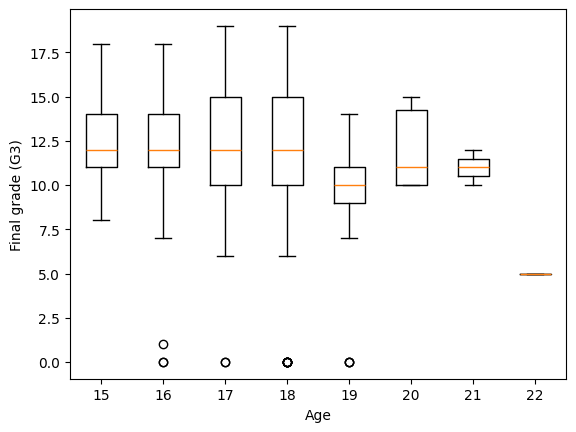

In [34]:
ages = sorted(df['age'].unique())

data = []
for a in ages:
  grades = df[df['age']==a]['G3']
  data.append(grades)

plt.boxplot(data)
plt.xlabel("Age")
plt.ylabel("Final grade (G3)")
plt.xticks(range(1, len(ages) + 1), ages)
plt.show()

Students aged between above 18 (19-22) get significantly lower grades than their younger colleagues. As I mentioned at the beggining of a notebook - portugese students graduate usually at age 18, so the older ones most likely remained at school due to previous class failures.  

# Impact of amount of time spent weekly on studying on final grade (G3)

Text(0, 0.5, 'Final grade (G3)')

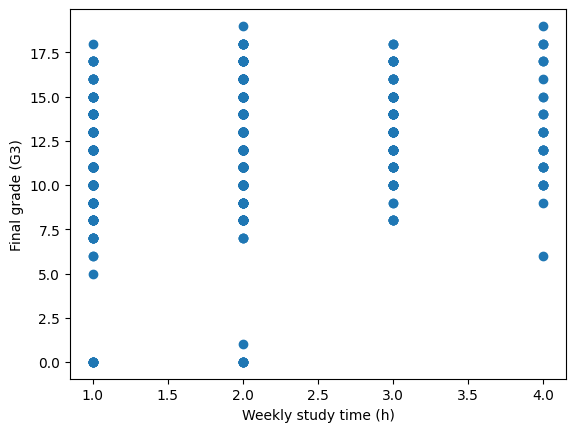

In [38]:
plt.scatter(df['studytime'], df['G3'])
plt.xlabel("Weekly study time (h)")
plt.ylabel("Final grade (G3)")

This scatter plot shows that students who spend more time studying each week generally achieve higher final grades (G3).  
However, good results are also attainable with minimal weekly study time, suggesting that study efficiency or other factors also play a significant role in performance.  
Overall, there is a positive trend between study time and grades, but it is not strictly linear. More hours do not always guarantee better results, but they increase the likelyhood of higher results.

# Impact of daily alcohol consumption on grades

In [40]:
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt

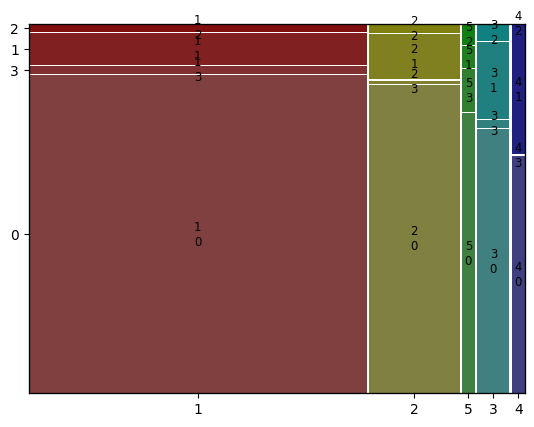

In [48]:
mosaic(df, ['Dalc', 'failures'])
plt.show()

Most students report low alcohol consumption (levels 1–2) and have no previous failures.  
As alcohol consumption increases, the number of students decreases, but the proportion of those who failed classes rises.  
This suggests a weak but noticeable trend — higher alcohol use during the week is associated with a greater likelihood of class failure.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 43.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 21.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 7.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 18.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 49.8% of the points cannot be place

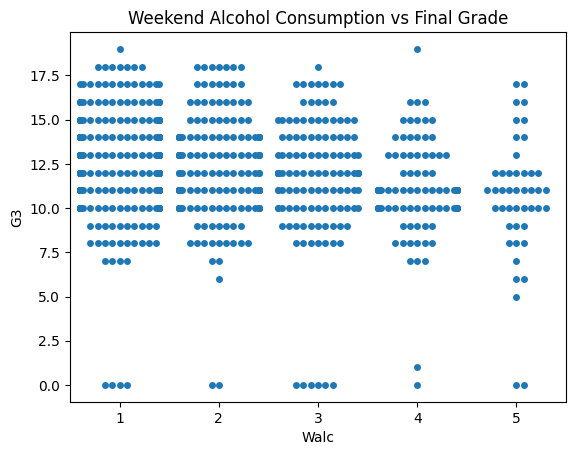

In [56]:
sns.swarmplot(x='Walc', y='G3', data=df)
plt.title("Weekend Alcohol Consumption vs Final Grade")
plt.show()

This plot confirms that there is no clear trend, but students who consume less alcohol (levels 1–2) tend to have slightly higher and more consistent grades.
Those with higher alcohol consumption (levels 4–5) show more variability and generally lower performance, suggesting that frequent weekend drinking may negatively affect academic results.

# Parents occupation vs. final grades (G3)


Text(0, 0.5, 'Final grade (G3)')

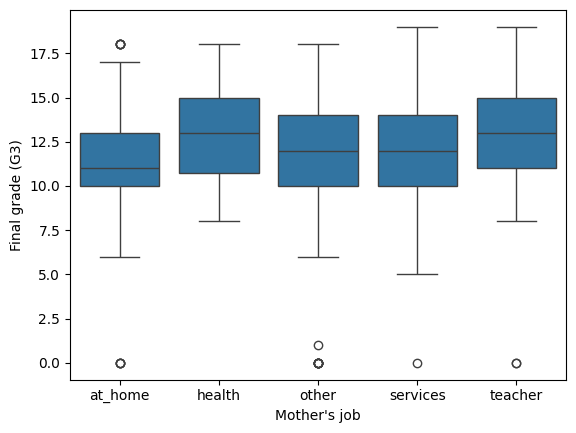

In [51]:
sns.boxplot(x='Mjob', y='G3', data=df)
plt.xlabel("Mother's job")
plt.ylabel("Final grade (G3)")


Text(0, 0.5, 'Final grade (G3)')

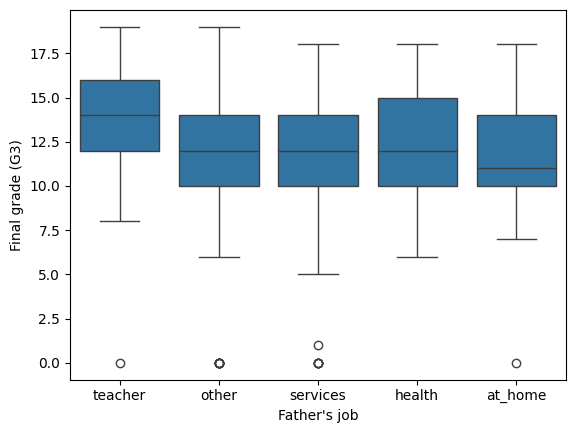

In [52]:
sns.boxplot(x='Fjob', y='G3', data=df)
plt.xlabel("Father's job")
plt.ylabel("Final grade (G3)")

The plots show that students whose mothers work as teachers or in the health sector tend to achieve slightly higher final grades compared to other occupations. A similar trend is visible for fathers, where students with teacher parents generally perform better. However, the differences between job categories are small, indicating that parental occupation has only a small impact on overall performance.

# Summary and conclusions

This analysis explored the student performance dataset containing information about 649 Portuguese students.  
The data included demographic factors, family background, lifestyle habits, and academic performance across three grading periods.

Overall, the results show that:
- **Grades (G1, G2, G3)** are strongly correlated. Students who perform well early tend to maintain high scores.  
- **Female students** achieve slightly higher grades on average than males.  
- **Urban students** generally perform better than rural ones, though rural students show more consistency.  
- **Older students (19–22)** tend to score lower, likely because they repeated classes.   
- **Absences** and **alcohol consumption** have a small but noticeable negative effect on grades.  
- **Study time** correlates positively with performance, but more hours do not guarantee success, they only increase the potential for higher grades.

In summary, academic success depends on multiple moderate influences rather than one dominant factor.  
Consistent study habits, healthy lifestyle, and regular school attendance appear to have the strongest positive impact on student outcomes.
